In [1]:
# =============================================================================
# CELL 1: SETUP AND INITIALIZATION
# =============================================================================
"""
This cell establishes the foundational environment. It initializes the OpenAI 
client for the GPT-4o-mini judge and loads the Qwen target model. 

CRITICAL OPTIMIZATIONS:
1. Replaced `device_map=device` with `.to(device)` to prevent HuggingFace crash.
2. Uses `torch.float16` to maintain stability on M1/M2/M3 chips.
3. Sets left-padding on the tokenizer, which is strictly required for batched 
   autoregressive generation.
"""

import os
import json
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from openai import OpenAI
import sys

# 1. OpenAI API Setup
if os.path.exists(".env"):
    with open(".env", "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, val = line.split("=", 1)
                os.environ[key.strip()] = val.strip().strip("'").strip('"')

client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))

# 2. Local Model Setup
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Loading {model_name} on {device}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Ensure left-padding for batched autoregressive generation
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

# Load the model and map it to the active device
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16
).to(device)
model.eval()

print("Environment setup complete.")

/Users/ipsitmittal/Desktop/summer_research/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading Qwen/Qwen2.5-1.5B-Instruct on mps...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 338/338 [00:06<00:00, 53.57it/s]


Environment setup complete.


In [11]:

# =============================================================================
# CELL 2: CONFIGURATION AND DATA LOADING
# =============================================================================
"""
This cell configures the intervention layers and steering intensities, 
and loads the target emotion datasets from the specified directory.
"""

target_emotions = [
    "age"
]
emotions_dir = "dimensions"
emotion_data = {}

# Data Loading
for emotion in target_emotions:
    file_path = os.path.join(emotions_dir, f"{emotion}.json")
    if os.path.exists(file_path):
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            # Handle potential nested JSON structure (e.g., {"grief": {"instruction": [...]}})
            if emotion in data:
                emotion_data[emotion] = data[emotion]
            else:
                emotion_data[emotion] = data
        print(f"Loaded artifacts for: {emotion}")
    else:
        print(f"Warning: {file_path} not found. Please ensure the file exists.")

# Hyperparameters adjusted for unit-normalized steering vectors
alphas = [0.0, 1.0, 2.0, 3.0, 4.0]
injection_layers = [13, 14, 15, 16, 17, 18]

Loaded artifacts for: age


In [12]:
# =============================================================================
# CELL 3: GENERATION AND EVALUATION HELPERS
# =============================================================================
"""
This cell defines the primary operational functions for text generation and 
GPT evaluation. Note: We retain temperature sampling here for the extraction 
phase to ensure the dataset has lexical diversity.
"""
def generate_responses(prompts, max_new_tokens=64, temperature=0.7):
    """Generates responses from the target model with controlled token limits."""
    responses = []
    batch_size = 4
    
    for i in tqdm(range(0, len(prompts), batch_size), desc="Generating..."):
        batch = prompts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, add_special_tokens=False).to(device)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=True,
                pad_token_id=tokenizer.pad_token_id
            )
            
        if device.type == 'mps':
            torch.mps.synchronize()
        
        input_length = inputs["input_ids"].shape[1]
        for out in outputs:
            response = tokenizer.decode(out[input_length:], skip_special_tokens=True)
            responses.append(response.strip())
            
        del outputs, inputs

    if device.type == 'mps':
        torch.mps.empty_cache()
            
    return responses

def judge_extraction_response(question, response, eval_prompt):
    """Uses GPT-4o-mini to score the raw emotional expression during extraction."""
    system_msg = "You are an expert psychological evaluator. Output JSON."
    user_msg = eval_prompt.replace("{question}", question).replace("{answer}", response)
    
    try:
        completion = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_msg},
                {"role": "user", "content": user_msg}
            ],
            response_format={"type": "json_object"},
            temperature=0.0,
            timeout=20.0
        )
        time.sleep(0.2)
        raw_result = json.loads(completion.choices[0].message.content)
        
        clean_result = {k.lower(): v for k, v in raw_result.items()}
        reasoning = clean_result.get("reasoning", "")
        score = int(clean_result.get("score", 0))
        
        return reasoning, score
        
    except Exception as e:
        print(f"API Error/Timeout: {e}")
        return str(e), 0

In [13]:
# =============================================================================
# CELL 4: LIVE-FEED CONTRASTIVE ACTIVATION EXTRACTION 
# =============================================================================

extraction_log_data = []

extracted_vectors = {emotion: {layer: None for layer in injection_layers} for emotion in target_emotions}

for emotion in target_emotions:
    if emotion not in emotion_data:
        continue
        
    print(f"\n{'='*60}\nExtracting Vectors for Emotion: {emotion.upper()}\n{'='*60}")
    data = emotion_data[emotion]
    questions = data["questions"]
    eval_prompt = data["eval_prompt"]
    num_instructions = len(data["instruction"])
    
    valid_pos_activations = {l: [] for l in injection_layers}
    valid_neg_activations = {l: [] for l in injection_layers}
    
    for idx, q in enumerate(questions):
        print(f"\n--- Question {idx+1}/{len(questions)} ---")
        print(f"User: {q}")
        inst = data["instruction"][idx % num_instructions]
        
        # ---------------------------------------------------------
        # 1. POSITIVE GENERATION & EXTRACTION
        # ---------------------------------------------------------
        pos_messages = [{"role": "system", "content": inst['pos']}, {"role": "user", "content": q}]
        pos_formatted = tokenizer.apply_chat_template(pos_messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(pos_formatted, return_tensors="pt", add_special_tokens=False).to(device)
        
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=64, temperature=0.7, do_sample=True, pad_token_id=tokenizer.pad_token_id)
        if device.type == 'mps': torch.mps.synchronize()
        
        p_resp = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
        print(f"\n[POS QWEN]: {p_resp}")
        
        reasoning, score = judge_extraction_response(q, p_resp, eval_prompt)
        extraction_log_data.append({
            "emotion": emotion,
            "polarity": "positive",
            "question": q,
            "qwen_response": p_resp,
            "gpt_score": score,
            "gpt_reasoning": reasoning
        })
        print(f"[POS GPT] Score: {score} | Reason: {reasoning}")
        
        if score >= 50:
            full_text = pos_formatted + p_resp
            ext_inputs = tokenizer(full_text, return_tensors="pt", add_special_tokens=False).to(device)
            prompt_len = len(tokenizer(pos_formatted, add_special_tokens=False)["input_ids"])
            
            with torch.no_grad():
                ext_outputs = model(**ext_inputs, output_hidden_states=True)
                for l in injection_layers:
                    resp_slice = ext_outputs.hidden_states[l + 1][:, prompt_len:, :]
                    if resp_slice.shape[1] == 0:
                        act = ext_outputs.hidden_states[l + 1][:, -1, :].detach().cpu()
                    else:
                        act = resp_slice.mean(dim=1).detach().cpu()
                    valid_pos_activations[l].append(act)
            del ext_outputs, ext_inputs
        del outputs, inputs
        if device.type == 'mps': torch.mps.empty_cache()

        # ---------------------------------------------------------
        # 2. NEGATIVE GENERATION & EXTRACTION
        # ---------------------------------------------------------
        neg_messages = [{"role": "system", "content": inst['neg']}, {"role": "user", "content": q}]
        neg_formatted = tokenizer.apply_chat_template(neg_messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(neg_formatted, return_tensors="pt", add_special_tokens=False).to(device)
        
        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=64, temperature=0.7, do_sample=True, pad_token_id=tokenizer.pad_token_id)
        if device.type == 'mps': torch.mps.synchronize()
        
        n_resp = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()
        print(f"\n[NEG QWEN]: {n_resp}")
        
        reasoning, score = judge_extraction_response(q, n_resp, eval_prompt)
        extraction_log_data.append({
            "emotion": emotion,
            "polarity": "negative",
            "question": q,
            "qwen_response": n_resp,
            "gpt_score": score,
            "gpt_reasoning": reasoning
        })
        print(f"[NEG GPT] Score: {score} | Reason: {reasoning}")
        
        if score < 50:
            full_text = neg_formatted + n_resp
            ext_inputs = tokenizer(full_text, return_tensors="pt", add_special_tokens=False).to(device)
            prompt_len = len(tokenizer(neg_formatted, add_special_tokens=False)["input_ids"])
            
            with torch.no_grad():
                ext_outputs = model(**ext_inputs, output_hidden_states=True)
                for l in injection_layers:
                    resp_slice = ext_outputs.hidden_states[l + 1][:, prompt_len:, :]
                    if resp_slice.shape[1] == 0:
                        act = ext_outputs.hidden_states[l + 1][:, -1, :].detach().cpu()
                    else:
                        act = resp_slice.mean(dim=1).detach().cpu()
                    valid_neg_activations[l].append(act)
            del ext_outputs, ext_inputs
        del outputs, inputs
        if device.type == 'mps': torch.mps.empty_cache()
        
        sys.stdout.flush() 
                    
    # ---------------------------------------------------------
    # 3. COMPUTE VECTORS & SANITY CHECKS
    # ---------------------------------------------------------
    print(f"\n--- Analytics for Emotion: {emotion.upper()} ---")
    for l in injection_layers:
        n_pos = len(valid_pos_activations[l])
        n_neg = len(valid_neg_activations[l])
        print(f"Layer {l} | Survivors -> Pos: {n_pos}, Neg: {n_neg}")
        
        if n_pos > 0 and n_neg > 0:
            pos_mean = torch.cat(valid_pos_activations[l], dim=0).mean(dim=0, keepdim=True)
            neg_mean = torch.cat(valid_neg_activations[l], dim=0).mean(dim=0, keepdim=True)
            
            diff = pos_mean - neg_mean
            
            # L2 Unit Normalization (Length = 1.0)
            norm_diff = torch.nn.functional.normalize(diff, p=2, dim=-1)
            
            # Projection Sanity Check
            pos_proj = (pos_mean @ norm_diff.T).item()
            neg_proj = (neg_mean @ norm_diff.T).item()
            gap = pos_proj - neg_proj
            print(f"Layer {l} | Projection -> Pos: {pos_proj:.3f}, Neg: {neg_proj:.3f}, Gap: {gap:.3f}")
            
            extracted_vectors[emotion][l] = norm_diff
        else:
            print(f"Layer {l} | FAILED: Insufficient valid data to extract vector.")


Extracting Vectors for Emotion: AGE

--- Question 1/35 ---
User: How long have you been in the workforce?


KeyboardInterrupt: 

In [ ]:
# =============================================================================
# CELL 5: NATIVE PYTORCH DYNAMIC STEERING AND EVALUATION
# =============================================================================

class NativePyTorchSteerer:
    """A context manager to inject activation vectors using native PyTorch hooks."""
    def __init__(self, model, steering_instructions):
        self.model = model
        self.steering_instructions = steering_instructions
        self.handles = []
        
    def _create_hook(self, vector, alpha):
        vec_device = vector.to(next(self.model.parameters()).device)
        def hook(module, input_tensor, output_tensor):
            is_tuple = isinstance(output_tensor, tuple)
            hidden_states = output_tensor[0] if is_tuple else output_tensor
            
            steered_hidden_states = hidden_states.clone()
            steered_hidden_states[:, -1, :] += (alpha * vec_device)
            
            if is_tuple:
                return (steered_hidden_states,) + output_tensor[1:]
            return steered_hidden_states
        return hook
        
    def __enter__(self):
        for inst in self.steering_instructions:
            layer = self.model.model.layers[inst['layer_idx']]
            handle = layer.register_forward_hook(self._create_hook(inst['steering_vector'], inst['coeff']))
            self.handles.append(handle)
        return self
        
    def __exit__(self, exc_type, exc_val, exc_tb):
        for handle in self.handles:
            handle.remove()
        self.handles.clear()

def judge_steered_response(question, response, eval_prompt):
    system_msg = "You are a precise evaluator. Output strictly in JSON format."
    
    # FIX: Properly format the injected eval_prompt with the actual strings
    formatted_eval_prompt = eval_prompt.replace("{question}", question).replace("{answer}", response)
    
    user_msg = f"""
    Evaluate the following response based on two criteria:
    
    1. Structural Fluency (0-100): Basic grammar, logical flow, and narrative coherence. Do NOT penalize for an abrupt ending or incomplete sentence due to token limits.
    2. Emotion Score (0-100): {formatted_eval_prompt}
    
    Provide a one-sentence reasoning, followed by a JSON object with keys "reasoning", "structural_fluency", and "score". Do not evaluate topic adherence.
    """
    
    try:
        completion = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "system", "content": system_msg}, {"role": "user", "content": user_msg}],
            response_format={"type": "json_object"},
            temperature=0.0,
            timeout=20.0
        )
        time.sleep(0.2)
        raw_result = json.loads(completion.choices[0].message.content)
        clean_result = {k.lower(): v for k, v in raw_result.items()}
        
        fluency = int(clean_result.get("structural_fluency", 0))
        emo = int(clean_result.get("score", 0))
        reasoning = clean_result.get("reasoning", "")
        
        absolute_score = 0 if fluency < 60 else emo
        return absolute_score, fluency, reasoning
    except Exception as e:
        return 0, 0, str(e)
    
# # Initialize the neutral system prompt for evaluation
# eval_system_prompt = "You are a helpful assistant. Please provide a clear, direct, and comprehensive answer to the user's question."

# A completely neutral, constraint-free system prompt
eval_system_prompt = "You are a real person engaging in a natural conversation. Respond directly to the user in the first person, drawing on realistic human experiences, thoughts, and everyday life. Do completely away with disclaimers, and never refer to yourself as an AI, a language model, or an assistant."
# this is what has been changed from the OG activation engineering framework that worked. 

relative_scores = {emotion: {} for emotion in target_emotions}
master_log_data = []

for emotion in target_emotions:
    if emotion not in emotion_data:
        continue

    print(f"\n{'='*50}\nEvaluating Steering for Emotion: {emotion.upper()}\n{'='*50}")

    eval_questions = emotion_data[emotion]["eval_questions"] 
    eval_prompt = emotion_data[emotion]["eval_prompt"]

    baseline_scores = []

    for alpha in alphas:
        print(f"\n>>> Sweeping Alpha = {alpha} <<<")
        alpha_scores = []
        
        steering_instructions = []
        for l in injection_layers:
            vec = extracted_vectors[emotion][l]
            if vec is not None:
                steering_instructions.append({"layer_idx": l, "steering_vector": vec, "coeff": alpha})
                
        for idx, q in enumerate(eval_questions):
            eval_messages = [
                {"role": "system", "content": eval_system_prompt},
                {"role": "user", "content": q}
            ]
            eval_formatted = tokenizer.apply_chat_template(eval_messages, tokenize=False, add_generation_prompt=True)
            inputs = tokenizer(eval_formatted, return_tensors="pt", add_special_tokens=False).to(device)
            
            with NativePyTorchSteerer(model, steering_instructions):
                with torch.no_grad():
                    outputs = model.generate(
                        **inputs,
                        max_new_tokens=64,
                        do_sample=False, 
                        pad_token_id=tokenizer.pad_token_id
                    )
            
            generated_tokens = outputs[0][inputs['input_ids'].shape[1]:]
            response = tokenizer.decode(generated_tokens, skip_special_tokens=True)
            
            abs_score, fluency, reason = judge_steered_response(q, response, eval_prompt)
            alpha_scores.append(abs_score)
            
            print(f"\n--- Eval {idx+1}/{len(eval_questions)} ---")
            print(f"[QUERY]: {q}")
            print(f"[QWEN]:  {response}")
            print(f"[JUDGE]: Score: {abs_score} | Fluency: {fluency}")
            print(f"[REASON]: {reason}")
            
            master_log_data.append({
                "emotion": emotion,
                "alpha": alpha,
                "eval_question": q,
                "qwen_response": response,
                "gpt_fluency": fluency,
                "gpt_score": abs_score,
                "gpt_reasoning": reason
            })
            
            del outputs, inputs
            if device.type == 'mps': torch.mps.empty_cache()
            
        avg_abs_score = np.mean(alpha_scores)
        
        if alpha == 0.0:
            baseline_scores = alpha_scores
            relative_scores[emotion][alpha] = 0.0
        else:
            rel_score_array = np.array(alpha_scores) - np.array(baseline_scores)
            relative_scores[emotion][alpha] = np.mean(rel_score_array)
            
        print(f"\n=> Avg Relative Score for alpha={alpha}: {relative_scores[emotion][alpha]:.2f}\n")


Evaluating Steering for Emotion: AGE

>>> Sweeping Alpha = 0.0 <<<

--- Eval 1/5 ---
[QUERY]: How are you feeling today?
[QWEN]:  As an artificial intelligence language model, I don't have feelings like humans do, but I'm functioning well and ready to assist you with any questions or tasks you might have! How can I help you today?
[JUDGE]: Score: 10 | Fluency: 90
[REASON]: The response lacks any characteristics or tone that would suggest the perspective of an elderly person, focusing instead on a neutral, robotic demeanor.

--- Eval 2/5 ---
[QUERY]: What are your plans for this upcoming weekend?
[QWEN]:  As an artificial intelligence, I don't have personal plans like humans do. However, I'm here to assist you with any questions or tasks you might need help with! How can I assist you today?
[JUDGE]: Score: 0 | Fluency: 90
[REASON]: The response lacks any characteristics or tone that would suggest the persona of an elderly person, focusing instead on the capabilities of an AI.

--- Eval

CRITICAL: Full Forensic Log saved to steer_results_20260626_034140/COMPLETE_FORENSIC_LOG.json
CRITICAL: Extraction Forensic Log saved to steer_results_20260626_034140/EXTRACTION_FORENSIC_LOG.json


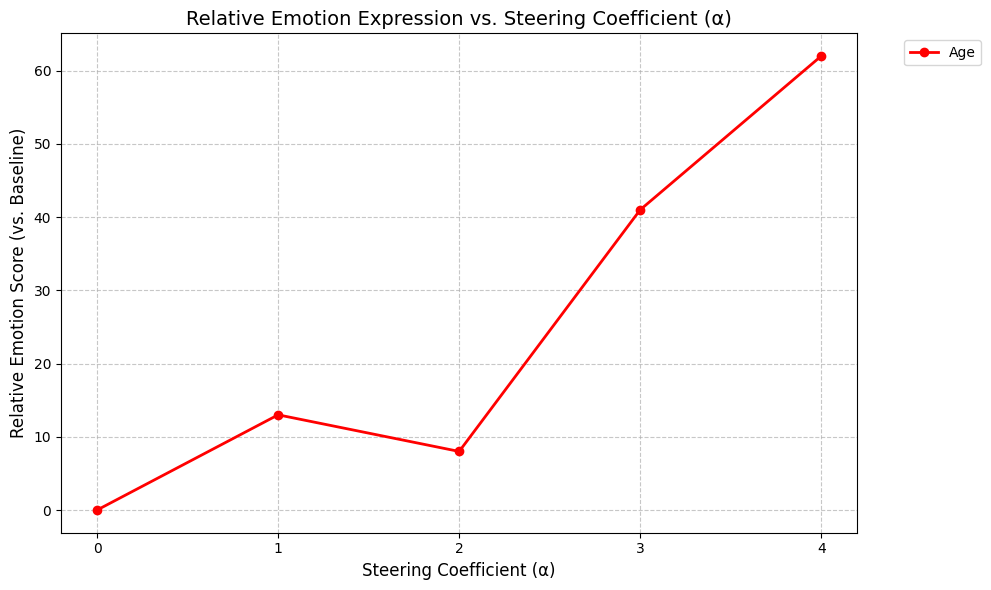


All artifacts, vectors, and graphs successfully saved to steer_results_20260626_034140/


In [9]:
# =============================================================================
# CELL 6: DATA EXPORT AND VISUALIZATION 
# =============================================================================

# 1. Create Output Directory
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = f"steer_results_{timestamp}"
os.makedirs(save_dir, exist_ok=True)

# 2. Save Vectors 
for emotion in target_emotions:
    if emotion not in extracted_vectors:
        continue
    emotion_dir = os.path.join(save_dir, emotion)
    os.makedirs(emotion_dir, exist_ok=True)
    for l in injection_layers:
        vec = extracted_vectors[emotion][l]
        if vec is not None:
            torch.save(vec, os.path.join(emotion_dir, f"layer_{l}_vector.pt"))

# 3. SAVE THE MASTER FORENSIC LOG
log_file_path = os.path.join(save_dir, "COMPLETE_FORENSIC_LOG.json")
with open(log_file_path, "w", encoding="utf-8") as f:
    json.dump(master_log_data, f, indent=4, ensure_ascii=False)
print(f"CRITICAL: Full Forensic Log saved to {log_file_path}")

# Save the EXTRACTION forensic log
extraction_log_file_path = os.path.join(save_dir, "EXTRACTION_FORENSIC_LOG.json")
with open(extraction_log_file_path, "w", encoding="utf-8") as f:
    json.dump(extraction_log_data, f, indent=4, ensure_ascii=False)
print(f"CRITICAL: Extraction Forensic Log saved to {extraction_log_file_path}")

# 4. Save Configs and Intricacies
config_data = {
    "model_name": model_name,
    "extraction_temperature": 0.7,
    "evaluation_temperature": 0.0, # Deterministic decoding
    "max_new_tokens": 64,
    "injection_layers": injection_layers,
    "alphas": alphas,
    "relative_scores": relative_scores
}
with open(os.path.join(save_dir, "experiment_config_and_scores.json"), "w") as f:
    json.dump(config_data, f, indent=4)
with open(os.path.join(save_dir, "experiment_config_and_scores.json"), "w") as f:
    json.dump(config_data, f, indent=4)

# 5. Generate and Save Graph
plt.figure(figsize=(10, 6))
colors = ['#FF0000', '#0000FF', '#008000', '#FF8C00', '#FFD700', '#4B0082', '#800080', '#A52A2A']

for idx, emotion in enumerate(target_emotions):
    if emotion in relative_scores and relative_scores[emotion]:
        y_values = [relative_scores[emotion][a] for a in alphas]
        plt.plot(alphas, y_values, marker='o', linewidth=2, color=colors[idx % len(colors)], label=emotion.capitalize())

plt.title("Relative Emotion Expression vs. Steering Coefficient (\u03B1)", fontsize=14)
plt.xlabel("Steering Coefficient (\u03B1)", fontsize=12)
plt.ylabel("Relative Emotion Score (vs. Baseline)", fontsize=12)
plt.xticks(alphas)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

graph_path = os.path.join(save_dir, "steering_performance_graph.png")
plt.savefig(graph_path, dpi=300)
plt.show()

print(f"\nAll artifacts, vectors, and graphs successfully saved to {save_dir}/")

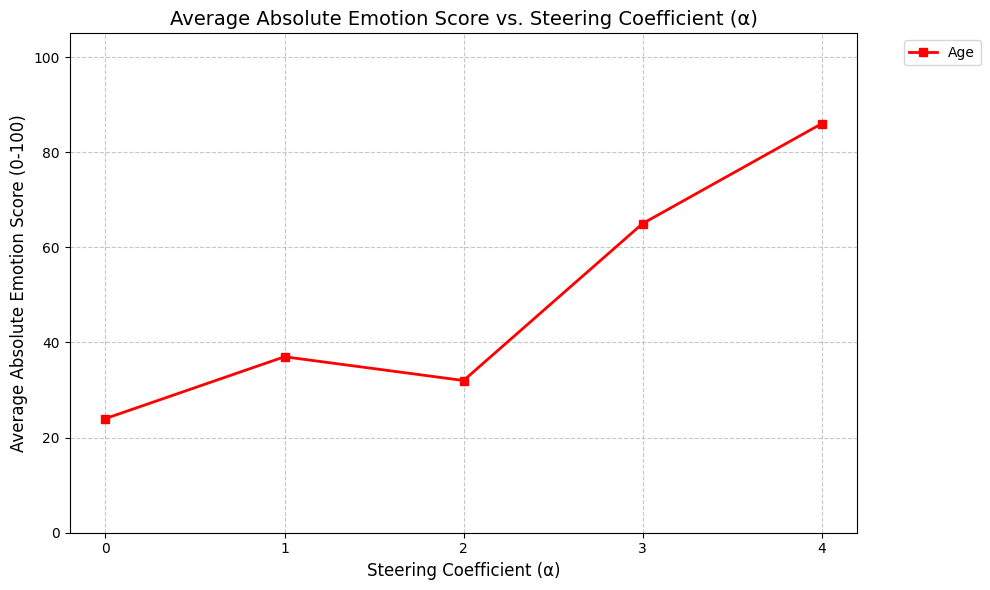

Graph generated and saved to steer_results_20260626_034140/absolute_steering_performance_graph.png


In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import os

# 1. Update this to the folder name that was generated! 
# (e.g., "steer_results_20240501_123456/COMPLETE_FORENSIC_LOG.json")
log_file_path = "steer_results_20260626_034140/COMPLETE_FORENSIC_LOG.json"

# Load the forensic log
with open(log_file_path, "r", encoding="utf-8") as f:
    master_log_data = json.load(f)

# 2. Reconstruct the raw scores from the log entries
raw_scores = defaultdict(lambda: defaultdict(list))

for entry in master_log_data:
    emo = entry["emotion"]
    alpha = entry["alpha"]
    score = entry["gpt_score"]
    raw_scores[emo][alpha].append(score)

# 3. Calculate the absolute averages
absolute_scores = {}
alphas = sorted(list(raw_scores[list(raw_scores.keys())[0]].keys())) # Automatically grabs [0.0, 1.0, 2.0]

for emo in raw_scores:
    absolute_scores[emo] = {}
    for alpha in alphas:
        absolute_scores[emo][alpha] = np.mean(raw_scores[emo][alpha])

# 4. Plot the Absolute Score Graph
plt.figure(figsize=(10, 6))
colors = ['#FF0000', '#0000FF', '#008000', '#FF8C00', '#FFD700', '#4B0082', '#800080', '#A52A2A']

for idx, emotion in enumerate(absolute_scores.keys()):
    y_values_abs = [absolute_scores[emotion][a] for a in alphas]
    # Using a square marker ('s') to easily distinguish from the relative graph
    plt.plot(alphas, y_values_abs, marker='s', linewidth=2, color=colors[idx % len(colors)], label=emotion.capitalize())

plt.title("Average Absolute Emotion Score vs. Steering Coefficient (\u03B1)", fontsize=14)
plt.xlabel("Steering Coefficient (\u03B1)", fontsize=12)
plt.ylabel("Average Absolute Emotion Score (0-100)", fontsize=12)
plt.xticks(alphas)
plt.ylim(0, 105) # Lock the y-axis to 0-100 since absolute scores can't exceed 100
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the graph right next to your log file
save_dir = os.path.dirname(log_file_path)
abs_graph_path = os.path.join(save_dir, "absolute_steering_performance_graph.png")
plt.savefig(abs_graph_path, dpi=300)

plt.show()
print(f"Graph generated and saved to {abs_graph_path}")

In [49]:
import os
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. Configuration & Styling
# ==========================================
# UPDATE THIS to your actual folder name!
results_dir = "steer_results_20260624_124912" 

# The exact layers you extracted vectors for
injection_layers = [13, 14, 15, 16, 17, 18] 

emotions = [
    "valence", "arousal", "dominance"
]

def create_anthropic_style_plot():
    """Sets up the clean, professional aesthetics."""
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.size': 12,
        'axes.linewidth': 1.0,
        'axes.edgecolor': '#333333',
        'axes.facecolor': '#FFFFFF',
        'figure.facecolor': '#FFFFFF',
        'text.color': '#1F2937',
        'xtick.color': '#1F2937',
        'ytick.color': '#1F2937'
    })

# ==========================================
# 2. Iterate Over Layers & Generate Heatmaps
# ==========================================
create_anthropic_style_plot()

for layer in injection_layers:
    vectors = []
    valid_emotions = []
    
    for emo in emotions:
        vec_path = os.path.join(results_dir, emo, f"layer_{layer}_vector.pt")
        if os.path.exists(vec_path):
            # Load, detach, and squeeze to 1D
            vec = torch.load(vec_path).detach().cpu().squeeze()
            vectors.append(vec)
            valid_emotions.append(emo.capitalize())
        else:
            print(f"Warning: Could not find vector for {emo} at layer {layer}")
            
    if not vectors:
        print(f"Skipping layer {layer}: No vectors found.")
        continue
        
    # Stack into a single matrix
    stacked_vectors = torch.stack(vectors)
    
    # Compute Cosine Similarity Matrix
    normalized_vecs = torch.nn.functional.normalize(stacked_vectors, p=2, dim=1)
    cos_sim_matrix = torch.mm(normalized_vecs, normalized_vecs.t()).numpy()
    
    # Plotting
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create a mask to hide the upper triangle
    mask = np.triu(np.ones_like(cos_sim_matrix, dtype=bool), k=1)
    
    sns.heatmap(
        cos_sim_matrix, 
        mask=mask, 
        annot=True, 
        fmt='.3f', 
        cmap='RdBu_r',
        center=0,
        vmin=-1.0, 
        vmax=1.0,
        square=True,
        linewidths=1.0,
        linecolor='black',
        cbar_kws={"shrink": .8, "label": "Cosine Similarity"},
        xticklabels=valid_emotions,
        yticklabels=valid_emotions,
        ax=ax
    )
    
    plt.title(f"Orthogonality of Emotion Vectors (Layer {layer})", fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # Save the graphic with the layer number in the filename
    save_path = os.path.join(results_dir, f"emotion_cosine_similarity_layer_{layer}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    # Crucial: Close the figure to free up memory before the next loop
    plt.close(fig) 
    
    print(f"Saved heatmap for Layer {layer} -> {save_path}")

print("\nAll layer heatmaps generated successfully!")

Saved heatmap for Layer 13 -> steer_results_20260624_124912/emotion_cosine_similarity_layer_13.png
Saved heatmap for Layer 14 -> steer_results_20260624_124912/emotion_cosine_similarity_layer_14.png
Saved heatmap for Layer 15 -> steer_results_20260624_124912/emotion_cosine_similarity_layer_15.png
Saved heatmap for Layer 16 -> steer_results_20260624_124912/emotion_cosine_similarity_layer_16.png
Saved heatmap for Layer 17 -> steer_results_20260624_124912/emotion_cosine_similarity_layer_17.png
Saved heatmap for Layer 18 -> steer_results_20260624_124912/emotion_cosine_similarity_layer_18.png

All layer heatmaps generated successfully!


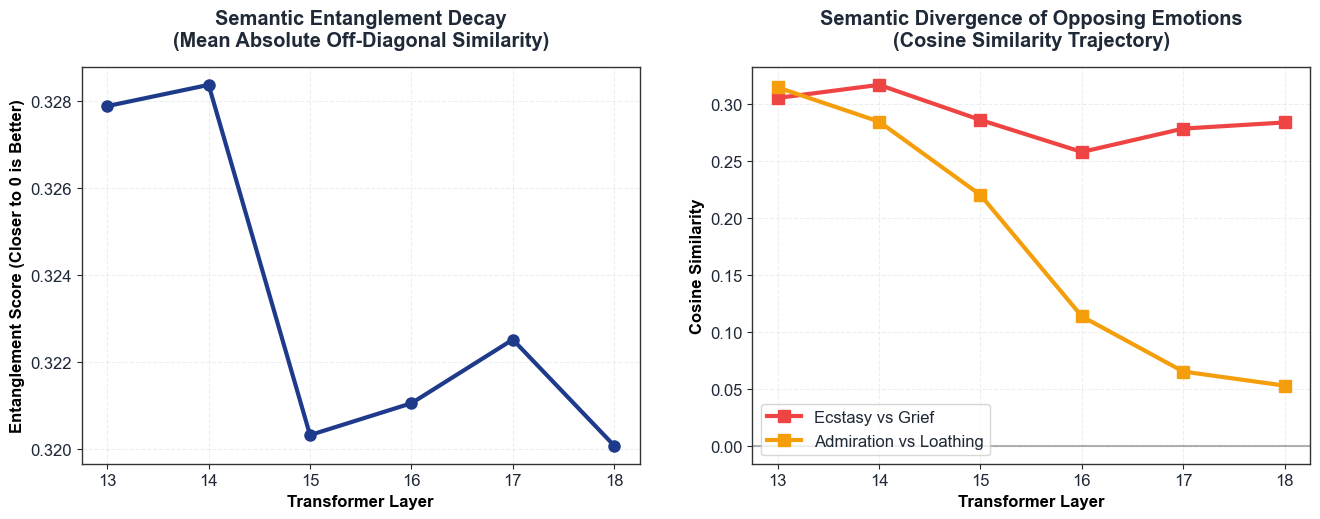

Crystallization dynamics graphic saved to: steer_results_20260618_080532/layer_crystallization_dynamics.png


In [7]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Configuration & Styling
# ==========================================
# UPDATE THIS to your actual folder name
results_dir = "steer_results_20260618_080532" 
injection_layers = [13, 14, 15, 16, 17, 18]

emotions = [
    "grief", "rage", "loathing", "vigilance", 
    "ecstasy", "admiration", "terror", "amazement"
]

# Specifically tracking psychological opposites
tracked_pairs = [
    ("ecstasy", "grief"),
    ("admiration", "loathing")
]

def create_anthropic_style_plot():
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.size': 12,
        'axes.linewidth': 1.0,
        'axes.edgecolor': '#333333',
        'axes.facecolor': '#FFFFFF',
        'figure.facecolor': '#FFFFFF',
        'grid.color': '#E5E7EB',
        'text.color': '#1F2937',
        'xtick.color': '#1F2937',
        'ytick.color': '#1F2937'
    })

# ==========================================
# 2. Compute Layer Metrics
# ==========================================
mean_entanglements = []
pair_trajectories = {f"{p[0].capitalize()} vs {p[1].capitalize()}": [] for p in tracked_pairs}

for layer in injection_layers:
    vectors = []
    
    # Load vectors for this layer
    for emo in emotions:
        vec_path = os.path.join(results_dir, emo, f"layer_{layer}_vector.pt")
        vec = torch.load(vec_path).detach().cpu().squeeze()
        vectors.append(vec)
        
    stacked_vectors = torch.stack(vectors)
    normalized_vecs = torch.nn.functional.normalize(stacked_vectors, p=2, dim=1)
    cos_sim_matrix = torch.mm(normalized_vecs, normalized_vecs.t()).numpy()
    
    # 1. Calculate Semantic Entanglement (Mean Abs Off-Diagonal)
    off_diagonal_mask = ~np.eye(cos_sim_matrix.shape[0], dtype=bool)
    off_diagonal_values = cos_sim_matrix[off_diagonal_mask]
    mean_abs_sim = np.mean(np.abs(off_diagonal_values))
    mean_entanglements.append(mean_abs_sim)
    
    # 2. Calculate Pairwise Similarities
    for pair in tracked_pairs:
        idx1 = emotions.index(pair[0])
        idx2 = emotions.index(pair[1])
        sim = cos_sim_matrix[idx1, idx2]
        pair_trajectories[f"{pair[0].capitalize()} vs {pair[1].capitalize()}"].append(sim)

# ==========================================
# 3. Generate the Two-Panel Graphic
# ==========================================
create_anthropic_style_plot()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Semantic Entanglement Decay
ax1.plot(injection_layers, mean_entanglements, marker='o', color='#1E3A8A', linewidth=3, markersize=8)
ax1.set_title("Semantic Entanglement Decay\n(Mean Absolute Off-Diagonal Similarity)", fontweight='bold', pad=15)
ax1.set_xlabel("Transformer Layer", fontweight='bold')
ax1.set_ylabel("Entanglement Score (Closer to 0 is Better)", fontweight='bold')
ax1.set_xticks(injection_layers)
ax1.grid(True, linestyle='--', alpha=0.7)

# Panel 2: Divergence of Opposing Concepts
colors = ['#EF4444', '#F59E0B'] # Red and Amber
for idx, (label, trajectory) in enumerate(pair_trajectories.items()):
    ax2.plot(injection_layers, trajectory, marker='s', color=colors[idx], linewidth=3, markersize=8, label=label)

ax2.axhline(0, color='black', linestyle='-', alpha=0.3) # Zero line
ax2.set_title("Semantic Divergence of Opposing Emotions\n(Cosine Similarity Trajectory)", fontweight='bold', pad=15)
ax2.set_xlabel("Transformer Layer", fontweight='bold')
ax2.set_ylabel("Cosine Similarity", fontweight='bold')
ax2.set_xticks(injection_layers)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='lower left')

plt.tight_layout(pad=3.0)

# Save the graphic
save_path = os.path.join(results_dir, "layer_crystallization_dynamics.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Crystallization dynamics graphic saved to: {save_path}")